In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import os, re
from scipy import optimize, constants as const
from scipy.optimize import curve_fit, leastsq
from scipy.interpolate import CubicSpline
from scipy.ndimage import gaussian_filter1d
from uncertainties import ufloat, unumpy
import uncertainties
from pandas import read_csv
from mechanical_model.linear_mech import Newtonian, JohnsonSegalman, FractionalMaxwell, Maxwell

In [2]:
DH = 91.542  #in kJ/mol
DS = 288.838 #in J/mol/K
Tm = 1e3*DH/DS #in K

# Effect of shorter strands
During DNA oligomer synthesis, nucleotides are added one by one. There is a probability $q$ that a nucleotide does not attach on any given strand. If so, the strand is capped and will not grow further. Although there is also a small failure rate of capping, we will not take it into account in the following.

The probability that a strand reaches the desired length $N$ is
$$P(N) = (1-q)^N$$
The probability that a strand is exactly of length $n<N$ is
$$P(n<N) = (1-q)^n q$$

However, during desalting strands shorter than 10 bases are eliminated. Probabilities thus become
$$P(N) = (1-q)^{N-10}$$
$$P(10<n<N) = (1-q)^{n-10} q$$

Each strand of Y16SE6 should be built as
1. A first arm of 16 bases
2. A central join of 2 bases
3. A second arm of 16 bases
4. A sticky end of 6 bases
The total desired length is thus N=40.

0.011818767940963149


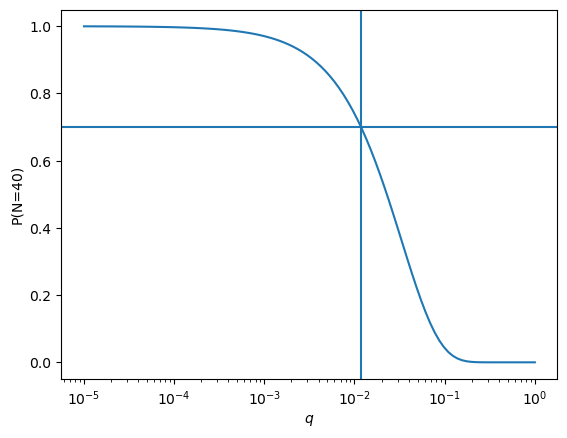

In [3]:
qs = np.logspace(-5,0,100)
plt.plot(qs, (1-qs)**(40-10))
plt.xscale('log')
plt.ylabel('P(N=40)')
plt.xlabel('$q$')
plt.axhline(0.7)
q40 = 1-0.7**(1/30)
plt.axvline(q40)
print(q40)

To have 70% of strands that are full length (Eurogen Tech), the error on each base addition is around 1%. What is the distribution of lengths for that error rate?

Text(0, 0.5, 'PDF')

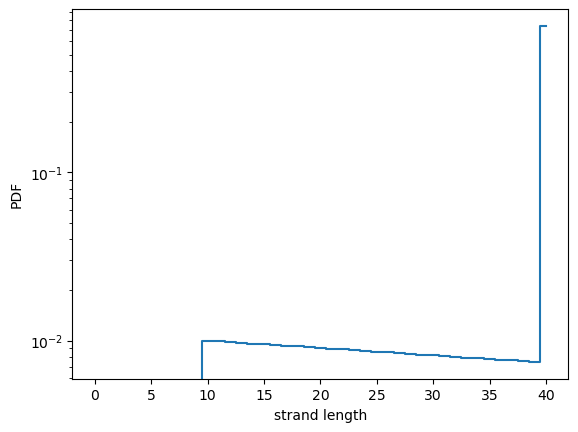

In [4]:
q = 1e-2
plt.step(np.arange(41), [0]*10 + [(1-q)**(n-10) * q for n in range(10,40)]+[(1-q)**(40-10)], where='mid')
plt.yscale('log')
plt.xlabel('strand length')
plt.ylabel('PDF')

In [5]:
#q=1e-2
print(f'{100*(1-q)**(40-10):.2f}% of the strands have full length')
print(f'{100*((1-q)**(34-10) - (1-q)**(40-10)):.2f}% of the strands have 2 arms but short sticky ends')
print(f'{100*((1-q)**(16-10) - (1-q)**(34-10)):.2f}% of the strands assemble one NS arm, but only partially the other arm')
print(f'{100*(1 - (1-q)**(16-10)):.2f}% of the strands assemble only partially a single arm')

73.97% of the strands have full length
4.60% of the strands have 2 arms but short sticky ends
15.58% of the strands assemble one NS arm, but only partially the other arm
5.85% of the strands assemble only partially a single arm


In [6]:
print(f'{100*(1-q)**(34-10):.2f}% of the strands have 2 full arms, among which')
pSE_length = np.zeros(7)
for i in range(6):
    pSE_length[i] = (1-q)**(34+i-10)*q/(1-q)**(34-10)
    print(f'\t- {100*pSE_length[i]: 4.2f}% of the SE are {i} bases long')
pSE_length[6] = (1-q)**(40-10)/((1-q)**(34-10))
print(f'\t- {100*pSE_length[6]:.2f}% of the SE are 6 bases long')

78.57% of the strands have 2 full arms, among which
	-  1.00% of the SE are 0 bases long
	-  0.99% of the SE are 1 bases long
	-  0.98% of the SE are 2 bases long
	-  0.97% of the SE are 3 bases long
	-  0.96% of the SE are 4 bases long
	-  0.95% of the SE are 5 bases long
	- 94.15% of the SE are 6 bases long


If the assembly of NS was non cooperative, the probability to assemble a NS from 3 strands that have each 2 full arms would be $P(n\geq 34)^3$%.

In [7]:
print(f'{100*(1-q)**(3*(34-10)):.2f}% of the nanostar would be made of 3 strands that have each 2 full arms in case of non cooperative assembly')
print(f'{100*(1-q)**(34-10):.2f}% of the nanostar would be made of 3 strands that have each 2 full arms in case of cooperative assembly')

48.50% of the nanostar would be made of 3 strands that have each 2 full arms in case of non cooperative assembly
78.57% of the nanostar would be made of 3 strands that have each 2 full arms in case of cooperative assembly


Hopefully, the assembly is cooperative and strands with 2 full arms will assemble more readily together. We will thus consider that the probability to assemble a NS from 3 strands that have each 2 full arms is $P(n\geq 34)$. The real concentration of NS is thus lower than expected.

The DNA concentration, i.e. the number of nucleotide bases in the system, has been estimated by absobance spectroscopy and converted to strand molar concentration by supposing that every strand is 40 bases long. Instead, we should use the mean length
$$\bar{n} = N (1-q)^{N-10} + \sum_{n=10}^{N-1} n (1-q)^{n-10} q$$

The ratio between actual fully-formed NS concentration and originally estimated NS concentration is thus
$$\frac{\rho_0^\mathrm{real}}{\rho_0} = P(n\geq 34) \frac{N}{\bar{n}}$$

In [8]:
quantitiy = np.array([0]*10+[n*(1-q)**(n-10) * q for n in range(10,40)]+[40*(1-q)**(40-10)])
print(f'Average strand length is {quantitiy.sum():.1f} instead of 40')
print(f'Concentration of fully-formed NS is only {100*(1-q)**(34-10) * 40/quantitiy.sum():.2f}% of the originally measured concentration')

Average strand length is 35.8 instead of 40
Concentration of fully-formed NS is only 87.86% of the originally measured concentration


SE assembly is frustrated by geometry and is probably not cooperative.
The probability of meeting between a SE of length $i$ and a SE of length $j$ is $p_i p_j$, and its binding probability is $p_{\mathrm{SE}k}$ with $k=\min(i,j)$.

Conversely, bonds with binding probability $p_{\mathrm{SE}i}$ have a meeting probability $p_i\sum_{j=i}^6 p_j$

In [9]:
print('Among the bonds between fully formed nanostars')
for i in range(7):
    print(f'- {100*pSE_length[i]*pSE_length[i:].sum(): 4.2f}% follow p_SE{i}(T)')

Among the bonds between fully formed nanostars
-  1.00% follow p_SE0(T)
-  0.98% follow p_SE1(T)
-  0.96% follow p_SE2(T)
-  0.94% follow p_SE3(T)
-  0.92% follow p_SE4(T)
-  0.90% follow p_SE5(T)
-  88.64% follow p_SE6(T)


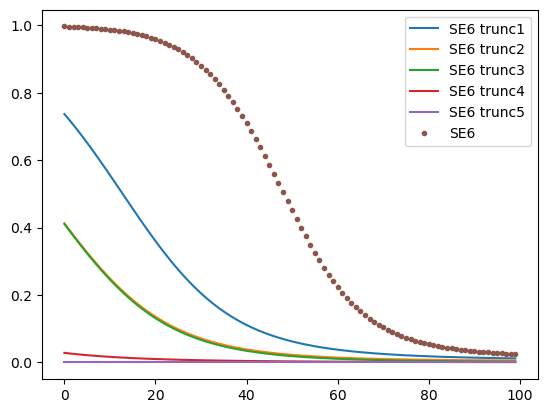

In [10]:
C_NS=1e-3
SE = 6
TsC = np.arange(0, 100)
TsK = const.convert_temperature(TsC, 'C', 'K')
for dtrunc in range(1,6):
    pSEdata = read_csv(f'../simulations/melting_SE{SE}/SE{SE}_{int(np.ceil(C_NS*3e6)):d}uM_truncated{dtrunc:d}.tsv', sep='\t').rename(columns={'# temperature':'T'})
    pSE = CubicSpline(pSEdata['T'], pSEdata['SE+SE']/(1.5*C_NS))
    plt.plot(TsC, pSE(TsC), label=f'SE{SE} trunc{dtrunc}')
pSEdata = read_csv(f'../simulations/melting_SE{SE}/SE{SE}_{int(np.ceil(C_NS*3e6)):d}uM_complexes_concentration_melting-1.tsv', sep='\t').rename(columns={'# temperature':'T'})
pSE6 = CubicSpline(pSEdata['T'], pSEdata['SE+SE']/(1.5*C_NS))
plt.plot(TsC, pSE6(TsC), '.', label=f'SE{SE}')
plt.legend()

Load Rheometer data to compare

In [11]:
dirname = os.path.dirname('.')

In [12]:
def get_moduli(filename):
    data = np.loadtxt(filename, skiprows=2, delimiter='\t')
    Temp = data[0,6]
    freq, Gp, Gpp, tandelta = np.transpose(data[:,2:6])
    torque = np.transpose(data[:,7])
    mask = (Gp != 0) & (Gpp != 0)
    freq, Gp, Gpp, tandelta, torque = freq[mask], Gp[mask], Gpp[mask], tandelta[mask], torque[mask]
    return Temp, freq, Gp, Gpp, tandelta, torque

def get_old_csv(filename):
    f = read_csv(filename, sep=";", decimal='.', header=0, dtype=str, encoding ='cp1252', usecols=range(12))
    f = f[f.Status.isna()]
    f = f[(f['Storage Modulus'].astype(float)!=0) & (f['Loss Modulus'].astype(float)!=0)]
    T = float(f['Temperature'].iloc[0])
    freq, Gp, Gpp, tandelta, torque = f[['Frequency', 'Storage Modulus', 'Loss Modulus', 'Damping Factor', 'Torque']].astype(float).to_numpy().T
    return T, freq, Gp, Gpp, tandelta, torque

In [13]:
well_annealed = [
    get_moduli(os.path.join(dirname, f'../rheometer/20250120/Y6-FS-{i}.tsv'))
    for i in [4,5,6,7,8]
]
strange_sample = [
   get_moduli(os.path.join(dirname, f'../rheometer/20250122/Y6-FS-{i}.tsv'))
   for i in [3,4,5,6,7,8]
]
old_rheo = [
    get_old_csv(os.path.join(dirname, f'/usr/home/mleocmach/Nextcloud/Hajar/rheometre/20240208/Y6-{i}.csv'))
    for i in [4,6,8,10,12]
]
old_bad_anneal = [
    get_old_csv(os.path.join(dirname, f'/usr/home/mleocmach/Nextcloud/Hajar/rheometre/20240205/Y6-{i}.csv'))
    for i in [34, 35, 25, 26, 22, 23, 19, 20, 17, 18]
]

In [14]:
def fit_fM(measurements):
    rheo_params = np.zeros((len(measurements), 5))
    for i, (T, freq, Gp, Gpp, tandelta, torque) in enumerate(measurements):
        omega = 2*np.pi * freq
        tau, alpha, beta = curve_fit(
            lambda ω, τ, α, β: np.log(FractionalMaxwell(alpha=α, beta=β, G=1, tau=τ).tandelta(ω)),
            omega,
            np.log(tandelta),
            [1, 1, 0],
            bounds=([0,0,0], [np.inf,1,1])
        )[0]
        if tau*np.max(omega)<1 or tau*np.min(omega)>1:
            continue
        G, = curve_fit(
            lambda ω, G: np.log(FractionalMaxwell(alpha=alpha, beta=beta, G=G, tau=tau).Gp(ω)),
            omega,
            np.log(Gp),
            [1e3],
            bounds=(0,np.inf)
        )[0]
        rheo_params[i] = T, alpha, beta, tau, G
    return rheo_params

In [15]:
"""From the value of the probability of a bound SE, the concentration in nanostar in mol/L and the temperature in Kelvin to elasticity in Pa"""
p2G = lambda p, T, c0: 1e3 * const.R * T * c0 * p**3 *3/2*(1-2/3)

p2G_tree = lambda p, T, c0: 1e3 * const.R * T * c0 * (np.maximum(0, 2*p-1)/p)**3 *3/2*(1-2/3)

In [16]:
c0 = 1e-3 #mol/L
pSEdata = read_csv(f'../simulations/SE6-only_3mM_concentration_melting.tsv', sep='\t').rename(columns={'# temperature':'T'})
#TsK = const.convert_temperature(pSEdata['T'], 'C', 'K')
pSE = pSEdata['SE+SE']/(1.5e6*c0)
pSEdata['p'] = pSEdata['SE+SE']/(1.5e6*c0)

2024/02/05 n=1.4788301284633927 tau0=3.953928502478083 ms
2024/02/08 n=2.756089050003964 tau0=0.07707326610961776 ms
2025/01/20 n=2.763011585714906 tau0=0.3106819674477594 ms


/tmp/ipykernel_1935774/2478093347.py:6: RuntimeWarning: invalid value encountered in log
  lambda ω, τ, α, β: np.log(FractionalMaxwell(alpha=α, beta=β, G=1, tau=τ).tandelta(ω)),


2025/01/22 n=2.6322162580729107 tau0=3.439757759014285 ms


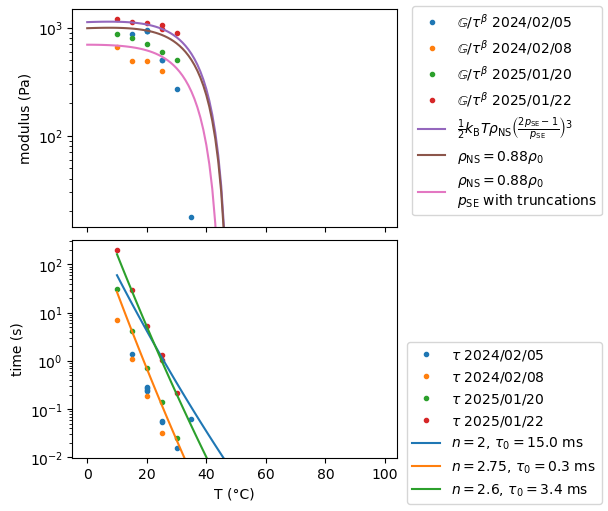

In [17]:
fig, axs = plt.subplots(2,1, figsize=(6,5), sharex=True, layout='constrained')

# good = params[:,2]>2*params[:,3]
# for iax, v, label in [
#     (0, params[:,1], r'$G$ DLS'),
#     (1, params[:,2]/params[:,1], r'$\eta/G$ DLS'),
# ]:
#     axs[iax].errorbar(unumpy.nominal_values(params[good,0]), unumpy.nominal_values(v[good]), unumpy.std_devs(v[good]), ls='none', marker='.', label=label)


#axs[0].plot(rheo_params[:,0], rheo_params[:,4] / rheo_params[:,3]**rheo_params[:,2], '.', label=r'$\mathbb{G}/\tau^\beta$ rheometer')
#axs[1].plot(rheo_params[:,0], rheo_params[:,3], '.', label=r'$\tau$ rheometer')

for label, measurements in zip(['2024/02/05', '2024/02/08', '2025/01/20', '2025/01/22'], [old_bad_anneal, old_rheo, well_annealed, strange_sample]):
    rheo_params = fit_fM(measurements)
    line, = axs[0].plot(rheo_params[:,0], rheo_params[:,4] / rheo_params[:,3]**rheo_params[:,2], '.', label=r'$\mathbb{G}/\tau^\beta$ '+label)
    axs[1].plot(rheo_params[:,0], rheo_params[:,3], '.', color=line.get_color(), label=r'$\tau$ '+label)
    good = rheo_params[:,3]>0
    n, A = curve_fit(
        lambda TsK, n, A: A + n*(DH*1e3 - TsK*DS)/(const.R*TsK),
        const.convert_temperature(rheo_params[good,0], 'C', 'K'),
        np.log(rheo_params[good,3]),
        [2, np.log(15e-3)],
    )[0]
    print(f'{label} n={n} tau0={np.exp(A)*1e3} ms') 
        

axs[0].set_ylabel('modulus (Pa)')
axs[1].set_ylabel('time (s)')
axs[-1].set_xlabel('T (°C)')
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylim(ax.get_ylim())

C_NS=1e-3
SE=6
pSEdata = read_csv(f'../simulations/melting_SE{SE}/SE{SE}_{int(np.ceil(C_NS*3e6)):d}uM_complexes_concentration_melting-1.tsv', sep='\t').rename(columns={'# temperature':'T'})
pSE6 = CubicSpline(pSEdata['T'], pSEdata['SE+SE']/(1.5*C_NS))
pSE6s = [pSE6]
for dtrunc in range(1,5):
    pSEdata = read_csv(f'../simulations/melting_SE{SE}/SE{SE}_{int(np.ceil(C_NS*3e6)):d}uM_truncated{dtrunc:d}.tsv', sep='\t').rename(columns={'# temperature':'T'})
    pSE6s.append(CubicSpline(pSEdata['T'], pSEdata['SE+SE']/(1.5*C_NS)))

pSE6_errors = lambda T: np.sum([pSE_length[i]*pSE_length[i:].sum() * pSE6s[6-i](T) for i in range(2,7)], 0)

rho_ratio = (1-q)**(34-10) * 40/quantitiy.sum()

axs[0].plot(
    TsC, p2G_tree(pSE6(TsC), const.convert_temperature(TsC, 'C', 'K'), c0), 
    label=r'$\frac{1}{2}k_\mathrm{B}T\rho_\mathrm{NS}\left(\frac{2 p_\mathrm{SE}-1}{p_\mathrm{SE}}\right)^3$'
)
axs[0].plot(
    TsC, p2G_tree(pSE6(TsC), const.convert_temperature(TsC, 'C', 'K'), rho_ratio*c0), 
    label=fr'$\rho_\mathrm{{NS}}= {rho_ratio:.2f}\rho_0$'
)
axs[0].plot(
    TsC, p2G_tree(pSE6_errors(TsC), const.convert_temperature(TsC, 'C', 'K'), rho_ratio*c0), 
    label=rf'''$\rho_\mathrm{{NS}}= {rho_ratio:.2f}\rho_0$
$p_\mathrm{{SE}}$ with truncations'''
)
# axs[0].plot(
#     TsC, p2G_tree(pSE, const.convert_temperature(pSEdata['T'], 'C', 'K'), 0.87*c0), 
#     label=r'$\frac{1}{2}k_\mathrm{B}T\times 0.87\rho_\mathrm{NS}\left(\frac{2 p_\mathrm{SE}-1}{p_\mathrm{SE}}\right)^3$'
# )
# axs[0].plot(
#     pSEdata['T'], 0.88*p2G_tree(pSE, const.convert_temperature(pSEdata['T'], 'C', 'K'), 0.87*c0), 
#     label=r'$\rho_\mathrm{NS}= 0.87\rho_0$ $p_\mathrm{SE}=0.88p_\mathrm{SE6}$'
# )

TsC = np.arange(10,70)
TsK = const.convert_temperature(TsC, 'C', 'K')

for n, tau0 in [(2,15e-3), (2.75,0.3e-3), (2.6,3.4e-3)]:
    axs[1].plot(TsC, tau0*np.exp(n*(DH*1e3 - TsK*DS)/(const.R*TsK)), label=fr'$n={n}$, $\tau_0={tau0*1e3:.1f}$ ms')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside right upper')
handles, labels = axs[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside right lower')

for ext in ['pdf', 'png']:
    plt.savefig(f'summary_modulus_time_errorsNS.{ext}')

### Model relaxation time

In [18]:
read_csv('../simulations/melting_SE6/thermo_params_SE6_trunc.tsv', delimiter='\t')

,Sequence,ΔH(kJ/mol),ΔS(J/mol/K)
0,GCTAGC,-39.2838,-100.5969
1,CTAGC,-17.8538,-41.5236
2,TAGC,-13.6095,-30.7836
3,AGC,-14.2966,-33.2156
4,GC,-7.9161,-17.1286


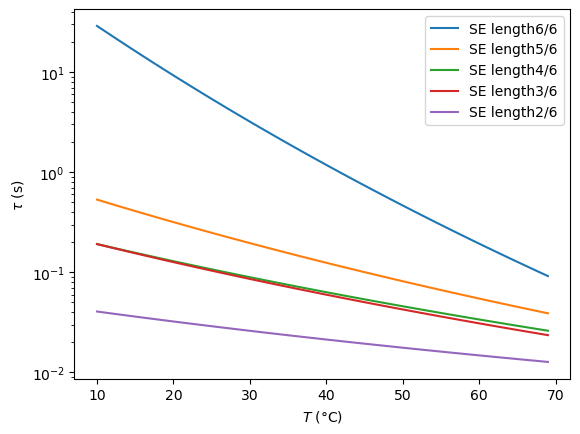

In [19]:
tau0 = 3e-3
n = 2
for i, (dH, dS) in enumerate(-np.loadtxt('../simulations/melting_SE6/thermo_params_SE6_trunc.tsv', delimiter='\t', skiprows=1, usecols=[1,2])):
    plt.plot(TsC, tau0*np.exp(n*(dH*1e3 - TsK*dS)/(const.R*TsK)), label=f'SE length{6-i}/6')
plt.xlabel('$T$ (°C)')
plt.ylabel(r'$\tau$ (s)')
plt.yscale('log')
plt.legend()


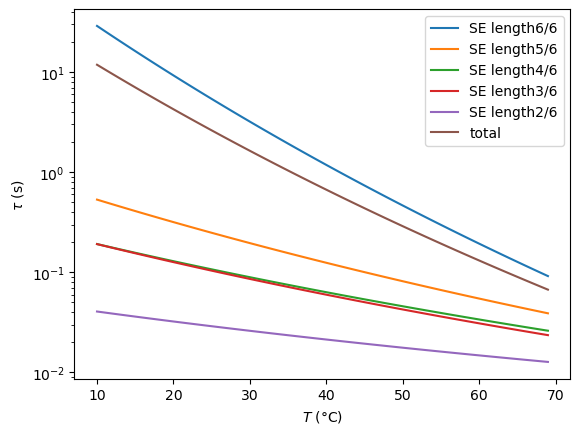

In [20]:
dHdStrunc = -np.loadtxt('../simulations/melting_SE6/thermo_params_SE6_trunc.tsv', delimiter='\t', skiprows=1, usecols=[1,2])
coeftrunc = np.array([pSE_length[i]*pSE_length[i:].sum() for i in range(2,7)])[::-1]
dHtrunc, dStrunc = np.sum(dHdStrunc*coeftrunc[:,None], 0)
tau0 = 3e-3
n = 2
for i, (dH, dS) in enumerate(-np.loadtxt('../simulations/melting_SE6/thermo_params_SE6_trunc.tsv', delimiter='\t', skiprows=1, usecols=[1,2])):
    plt.plot(TsC, tau0*np.exp(n*(dH*1e3 - TsK*dS)/(const.R*TsK)), label=f'SE length{6-i}/6')

plt.plot(TsC, tau0*np.exp(n*(dHtrunc*1e3 - TsK*dStrunc)/(const.R*TsK)), label=f'total')
plt.xlabel('$T$ (°C)')
plt.ylabel(r'$\tau$ (s)')
plt.yscale('log')
plt.legend()

For a rearrangement to occur, two bonds must be broken symultaneously. If all bonds are identical of enthalpy $\Delta H$ and entropy $\Delta S$, the typical time of rearrangement is
$$\tau_0 \left(\exp\frac{\Delta H -T\Delta S}{RT}\right)^2,$$
where we square the probability of breaking a single bond.

More generally, the typical rearrangement rate is
$$\frac{\tau_0}{\tau(T)} = \sum_{i,j} p_i p_j p_\mathrm{break}(i) p_\mathrm{break}(j),$$
where $p_i$ is the probability of a bond of type $i$, and $p_\mathrm{break}(i)$ is the probablity for a bond of type $i$ to break.

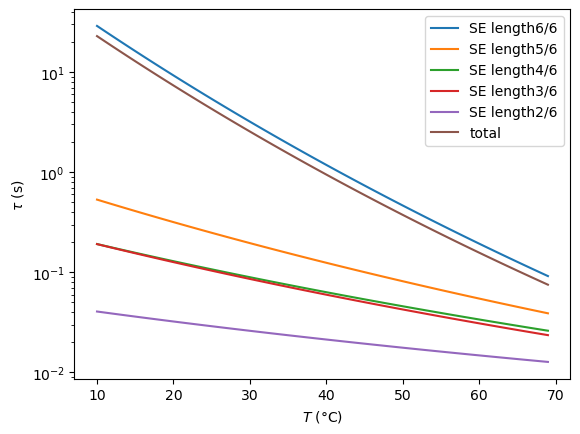

In [21]:
tau0 = 3e-3
n = 2
for i, (dH, dS) in enumerate(-np.loadtxt('../simulations/melting_SE6/thermo_params_SE6_trunc.tsv', delimiter='\t', skiprows=1, usecols=[1,2])):
    plt.plot(TsC, tau0*np.exp(n*(dH*1e3 - TsK*dS)/(const.R*TsK)), label=f'SE length{6-i}/6')

pij = coeftrunc[None,:] * np.exp((dHdStrunc[None,:,0]*1e3-TsK[:,None]*dHdStrunc[None,:,1])/(const.R*TsK[:,None]))
plt.plot(TsC, tau0*(pij[:,None,:]*pij[:,:,None]).sum((1,2)), label=f'total')
#plt.plot(TsC, tau0 / pij[:,0]**2)
plt.xlabel('$T$ (°C)')
plt.ylabel(r'$\tau$ (s)')
plt.yscale('log')
plt.legend()

2024/02/05 n=1.4788301284633927 tau0=3.953928502478083 ms
2024/02/08 n=2.756089050003964 tau0=0.07707326610961776 ms
2025/01/20 n=2.763011585714906 tau0=0.3106819674477594 ms


/tmp/ipykernel_1935774/2478093347.py:6: RuntimeWarning: invalid value encountered in log
  lambda ω, τ, α, β: np.log(FractionalMaxwell(alpha=α, beta=β, G=1, tau=τ).tandelta(ω)),


2025/01/22 n=2.6322162580729107 tau0=3.439757759014285 ms


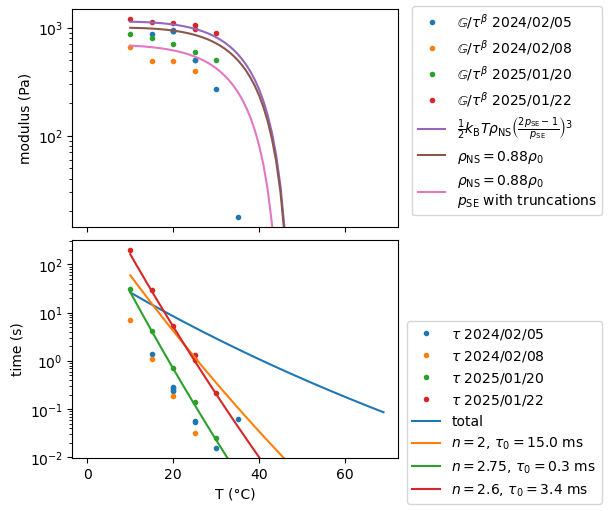

In [22]:
fig, axs = plt.subplots(2,1, figsize=(6,5), sharex=True, layout='constrained')

# good = params[:,2]>2*params[:,3]
# for iax, v, label in [
#     (0, params[:,1], r'$G$ DLS'),
#     (1, params[:,2]/params[:,1], r'$\eta/G$ DLS'),
# ]:
#     axs[iax].errorbar(unumpy.nominal_values(params[good,0]), unumpy.nominal_values(v[good]), unumpy.std_devs(v[good]), ls='none', marker='.', label=label)# 


#axs[0].plot(rheo_params[:,0], rheo_params[:,4] / rheo_params[:,3]**rheo_params[:,2], '.', label=r'$\mathbb{G}/\tau^\beta$ rheometer')
#axs[1].plot(rheo_params[:,0], rheo_params[:,3], '.', label=r'$\tau$ rheometer')

for label, measurements in zip(['2024/02/05', '2024/02/08', '2025/01/20', '2025/01/22'], [old_bad_anneal, old_rheo, well_annealed, strange_sample]):
    rheo_params = fit_fM(measurements)
    line, = axs[0].plot(rheo_params[:,0], rheo_params[:,4] / rheo_params[:,3]**rheo_params[:,2], '.', label=r'$\mathbb{G}/\tau^\beta$ '+label)
    axs[1].plot(rheo_params[:,0], rheo_params[:,3], '.', color=line.get_color(), label=r'$\tau$ '+label)
    good = rheo_params[:,3]>0
    n, A = curve_fit(
        lambda TsK, n, A: A + n*(DH*1e3 - TsK*DS)/(const.R*TsK),
        const.convert_temperature(rheo_params[good,0], 'C', 'K'),
        np.log(rheo_params[good,3]),
        [2, np.log(15e-3)],
    )[0]
    print(f'{label} n={n} tau0={np.exp(A)*1e3} ms')

TsC = np.arange(10,70)
TsK = const.convert_temperature(TsC, 'C', 'K')
pij = coeftrunc[None,:] * np.exp((dHdStrunc[None,:,0]*1e3-TsK[:,None]*dHdStrunc[None,:,1])/(const.R*TsK[:,None]))
axs[1].plot(TsC, np.exp(A)*(pij[:,None,:]*pij[:,:,None]).sum((1,2)), label=f'total')
        

axs[0].set_ylabel('modulus (Pa)')
axs[1].set_ylabel('time (s)')
axs[-1].set_xlabel('T (°C)')
for ax in axs:
    ax.set_yscale('log')
    ax.set_ylim(ax.get_ylim())

C_NS=1e-3
SE=6
pSEdata = read_csv(f'../simulations/melting_SE{SE}/SE{SE}_{int(np.ceil(C_NS*3e6)):d}uM_complexes_concentration_melting-1.tsv', sep='\t').rename(columns={'# temperature':'T'})
pSE6 = CubicSpline(pSEdata['T'], pSEdata['SE+SE']/(1.5*C_NS))
pSE6s = [pSE6]
for dtrunc in range(1,5):
    pSEdata = read_csv(f'../simulations/melting_SE{SE}/SE{SE}_{int(np.ceil(C_NS*3e6)):d}uM_truncated{dtrunc:d}.tsv', sep='\t').rename(columns={'# temperature':'T'})
    pSE6s.append(CubicSpline(pSEdata['T'], pSEdata['SE+SE']/(1.5*C_NS)))

pSE6_errors = lambda T: np.sum([pSE_length[i]*pSE_length[i:].sum() * pSE6s[6-i](T) for i in range(2,7)], 0)

rho_ratio = (1-q)**(34-10) * 40/quantitiy.sum()

axs[0].plot(
    TsC, p2G_tree(pSE6(TsC), const.convert_temperature(TsC, 'C', 'K'), c0), 
    label=r'$\frac{1}{2}k_\mathrm{B}T\rho_\mathrm{NS}\left(\frac{2 p_\mathrm{SE}-1}{p_\mathrm{SE}}\right)^3$'
)
axs[0].plot(
    TsC, p2G_tree(pSE6(TsC), const.convert_temperature(TsC, 'C', 'K'), rho_ratio*c0), 
    label=fr'$\rho_\mathrm{{NS}}= {rho_ratio:.2f}\rho_0$'
)
axs[0].plot(
    TsC, p2G_tree(pSE6_errors(TsC), const.convert_temperature(TsC, 'C', 'K'), rho_ratio*c0), 
    label=rf'''$\rho_\mathrm{{NS}}= {rho_ratio:.2f}\rho_0$
$p_\mathrm{{SE}}$ with truncations'''
)
# axs[0].plot(
#     TsC, p2G_tree(pSE, const.convert_temperature(pSEdata['T'], 'C', 'K'), 0.87*c0), 
#     label=r'$\frac{1}{2}k_\mathrm{B}T\times 0.87\rho_\mathrm{NS}\left(\frac{2 p_\mathrm{SE}-1}{p_\mathrm{SE}}\right)^3$'
# )
# axs[0].plot(
#     pSEdata['T'], 0.88*p2G_tree(pSE, const.convert_temperature(pSEdata['T'], 'C', 'K'), 0.87*c0), 
#     label=r'$\rho_\mathrm{NS}= 0.87\rho_0$ $p_\mathrm{SE}=0.88p_\mathrm{SE6}$'
# )

TsC = np.arange(10,70)
TsK = const.convert_temperature(TsC, 'C', 'K')

for n, tau0 in [(2,15e-3), (2.75,0.3e-3), (2.6,3.4e-3)]:
    axs[1].plot(TsC, tau0*np.exp(n*(DH*1e3 - TsK*DS)/(const.R*TsK)), label=fr'$n={n}$, $\tau_0={tau0*1e3:.1f}$ ms')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside right upper')
handles, labels = axs[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside right lower')

#for ext in ['pdf', 'png']:
#    plt.savefig(f'summary_modulus_time_errorsNS.{ext}')